# Omnichannel Sales Forecasting
**Architecture:** Data → Features → LightGBM + TFT + GARCH-X → Meta-learner → Output

Dataset: `Sales Records.csv` — 1,048,575 orders, Jan 2010 → Sep 2020 (11 years)  
- `Region + Sales Channel` is used as the **channel** dimension  
- `Item Type` is used as the **category** dimension  
- Target: `Total Revenue` (leaky columns Units Sold, Unit Price, Unit Cost, Total Cost, Total Profit excluded)

## Step 1 — Install packages

In [3]:
!pip install lightgbm pytorch-forecasting pytorch-lightning arch shap -q

## Step 2 — Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import shap

import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

from arch import arch_model

print('All imports OK')
print(f'GPU: {torch.cuda.is_available()}')

All imports OK
GPU: False


## Step 3 — Load Data

In [5]:
df_raw = pd.read_csv('Sales_Records.csv')

df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'])

# Region + Sales Channel combined → channel dimension
# Item Type                        → category dimension
# Total Revenue                    → target (Units Sold/Price/Cost columns excluded — they leak into target)
df_raw['channel']  = df_raw['Region'] + ' — ' + df_raw['Sales Channel']
df_raw['category'] = df_raw['Item Type']

df_raw = df_raw.rename(columns={
    'Order Date':    'date',
    'Total Revenue': 'sales_amount',
})

print(f'Rows       : {len(df_raw):,}')
print(f'Date range : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Channels   : {df_raw["channel"].nunique()} — {sorted(df_raw["channel"].unique().tolist())}')
print(f'Categories : {df_raw["category"].nunique()} — {sorted(df_raw["category"].unique().tolist())}')
print(f'Nulls      : {df_raw[["date","channel","category","sales_amount"]].isnull().sum().to_dict()}')
df_raw[['date','channel','category','sales_amount']].head()

Rows       : 1,000,000
Date range : 2010-01-01 → 2017-07-29
Channels   : 14 — ['Asia — Offline', 'Asia — Online', 'Australia and Oceania — Offline', 'Australia and Oceania — Online', 'Central America and the Caribbean — Offline', 'Central America and the Caribbean — Online', 'Europe — Offline', 'Europe — Online', 'Middle East and North Africa — Offline', 'Middle East and North Africa — Online', 'North America — Offline', 'North America — Online', 'Sub-Saharan Africa — Offline', 'Sub-Saharan Africa — Online']
Categories : 12 — ['Baby Food', 'Beverages', 'Cereal', 'Clothes', 'Cosmetics', 'Fruits', 'Household', 'Meat', 'Office Supplies', 'Personal Care', 'Snacks', 'Vegetables']
Nulls      : {'date': 0, 'channel': 0, 'category': 0, 'sales_amount': 0}


,date,channel,category,sales_amount
0,2012-07-27,Sub-Saharan Africa — Offline,Fruits,14862.69
1,2013-09-14,Middle East and North Africa — Online,Clothes,503890.08
2,2015-05-15,Australia and Oceania — Offline,Meat,151880.40
3,2017-05-17,Sub-Saharan Africa — Offline,Clothes,61415.36
4,2016-10-26,Europe — Offline,Beverages,188518.85


## Step 4 — Exploratory Data Analysis

## Chart 1 — Yearly + Monthly total revenue

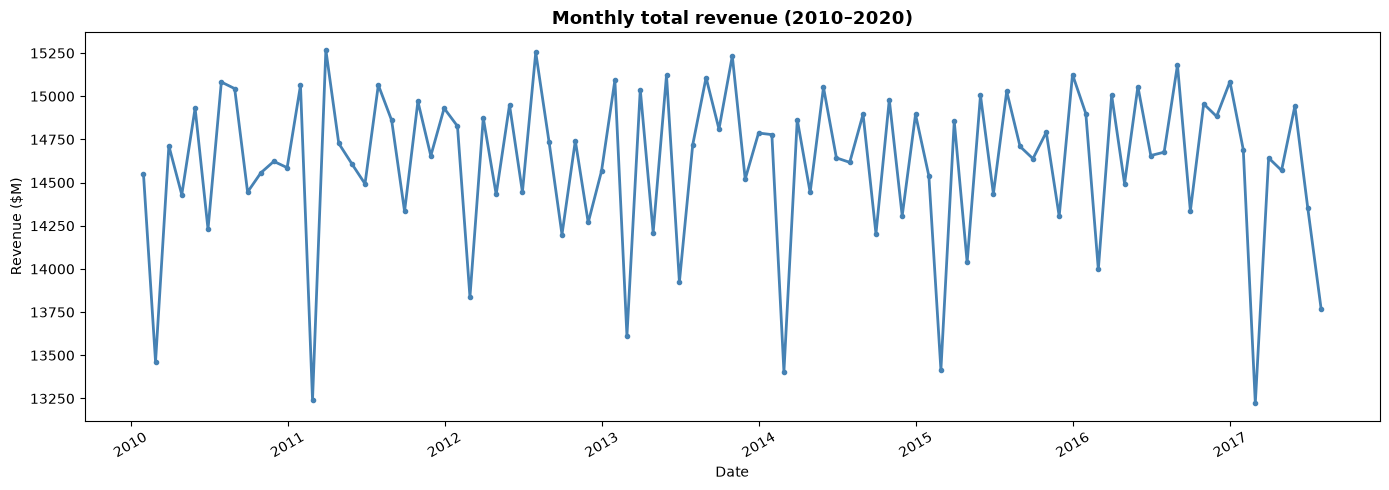

In [ ]:
monthly_total = df_raw.set_index('date')['sales_amount'].resample('ME').sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_total.index, monthly_total.values / 1e6,
         linewidth=2, color='steelblue', marker='o', ms=3)
plt.title('Monthly total revenue (2010–2020)', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($M)')
plt.xlabel('Date')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Chart 2 — Revenue by Region


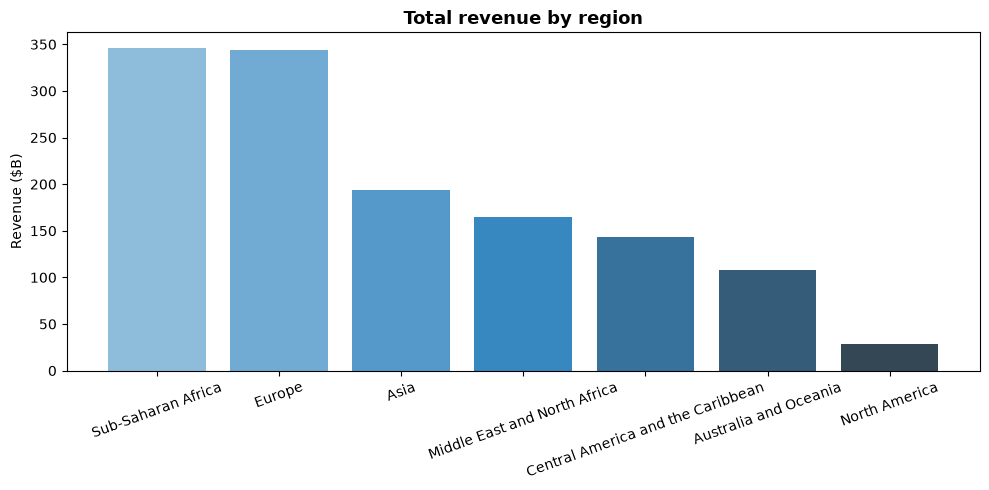

In [7]:
by_region = df_raw.groupby('Region')['sales_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(by_region.index, by_region.values / 1e9,
        color=sns.color_palette('Blues_d', len(by_region)))
plt.title('Total revenue by region', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($B)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Chart 3 — Revenue by Item Type

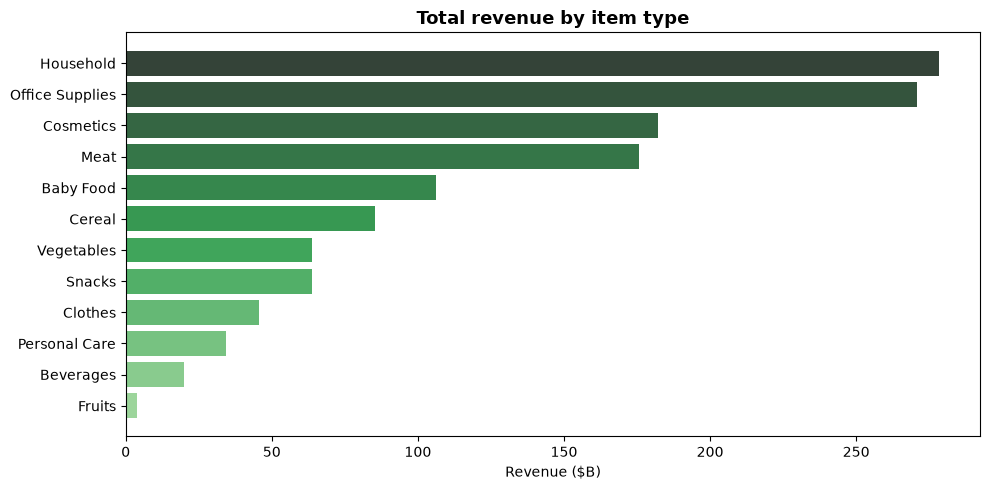

In [8]:
by_item = df_raw.groupby('category')['sales_amount'].sum().sort_values()

plt.figure(figsize=(10, 5))
plt.barh(by_item.index, by_item.values / 1e9,
         color=sns.color_palette('Greens_d', len(by_item)))
plt.title('Total revenue by item type', fontsize=13, fontweight='bold')
plt.xlabel('Revenue ($B)')
plt.tight_layout()
plt.show()

## Chart 4 — Online vs Offline split over time

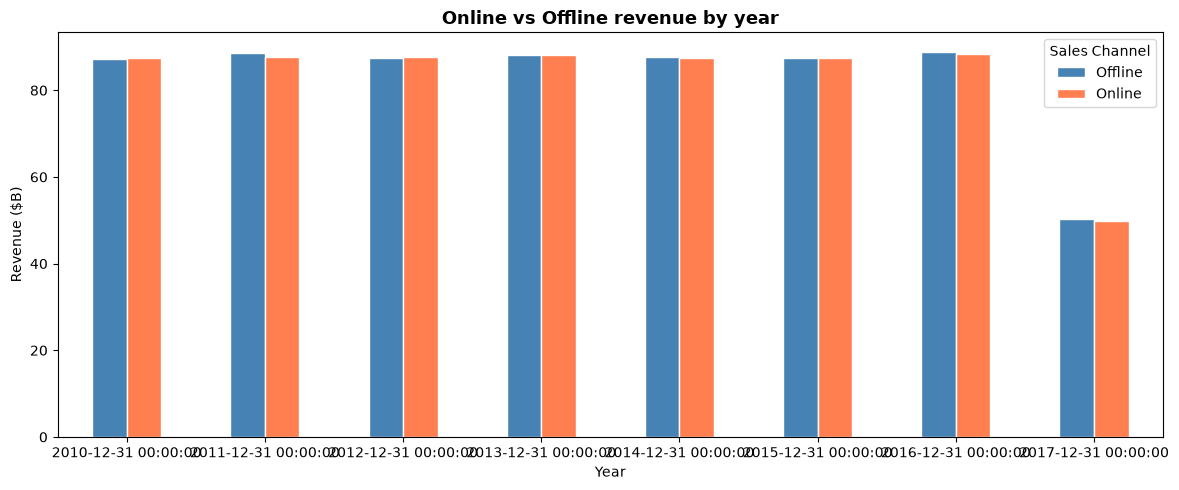

In [9]:
channel_monthly = (
    df_raw.groupby([pd.Grouper(key='date', freq='YE'), 'Sales Channel'])['sales_amount']
          .sum().unstack('Sales Channel') / 1e9
)

channel_monthly.plot(kind='bar', figsize=(12, 5),
                     color=['steelblue', 'coral'], edgecolor='white')
plt.title('Online vs Offline revenue by year', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($B)')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering
Aggregate orders → monthly per (channel × category), then build lag, rolling, calendar, and growth features.  
**11 years of data means all lag features (1m–12m) and YoY growth are fully valid.**

In [10]:
df_raw['year_month'] = df_raw['date'].dt.to_period('M')

# Aggregate to monthly — revenue only, no leaky columns

In [11]:
monthly = (
    df_raw.groupby(['year_month', 'channel', 'category'])
          .agg(sales_amount=('sales_amount', 'sum'))
          .reset_index()
)
monthly['date'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values(['channel', 'category', 'date']).reset_index(drop=True)

## ── Channel decomposition: each group's share of total monthly revenue

In [12]:
total_per_month          = monthly.groupby('date')['sales_amount'].transform('sum')
monthly['channel_share'] = monthly['sales_amount'] / (total_per_month + 1e-9)

## ── Calendar features

In [13]:
monthly['month']     = monthly['date'].dt.month
monthly['quarter']   = monthly['date'].dt.quarter
monthly['year']      = monthly['date'].dt.year
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)
monthly['qtr_sin']   = np.sin(2 * np.pi * monthly['quarter'] / 4)
monthly['qtr_cos']   = np.cos(2 * np.pi * monthly['quarter'] / 4)

## ── Lag features — all valid with 11 years of history

In [14]:
grp = monthly.groupby(['channel', 'category'])['sales_amount']
for lag in [1, 2, 3, 6, 12]:
    monthly[f'lag_{lag}m'] = grp.shift(lag)

## ── Rolling statistics

In [15]:
for w in [3, 6, 12]:
    monthly[f'roll_mean_{w}m'] = grp.shift(1).transform(lambda x: x.rolling(w, min_periods=1).mean())
    monthly[f'roll_std_{w}m']  = grp.shift(1).transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))

## ── YoY growth (valid because we have 11 years)

In [16]:
monthly['yoy_growth'] = (
    (monthly['sales_amount'] - grp.shift(12)) / (grp.shift(12) + 1e-9)
).replace([np.inf, -np.inf], 0).fillna(0)

## ── Month-over-month growth

In [17]:
monthly['mom_growth'] = grp.pct_change(1).replace([np.inf, -np.inf], 0).fillna(0)

## ── Encode categoricals

In [18]:
le_ch  = LabelEncoder()
le_cat = LabelEncoder()
monthly['channel_enc']  = le_ch.fit_transform(monthly['channel'])
monthly['category_enc'] = le_cat.fit_transform(monthly['category'])
monthly['group_id']     = monthly['channel'] + '__' + monthly['category']

## ── Integer time index (required by TFT)

In [19]:
min_month           = monthly['date'].dt.to_period('M').min()
monthly['time_idx'] = (monthly['date'].dt.to_period('M') - min_month).apply(lambda x: x.n)

## Drop warmup rows (first 12 months per group for lag_12m to be valid)

In [20]:
monthly = monthly.dropna(subset=['lag_1m', 'lag_3m', 'lag_12m']).reset_index(drop=True)

In [21]:
print(f'Monthly feature table : {monthly.shape}')
print(f'Groups (channel x cat): {monthly["group_id"].nunique()}')
print(f'Months available      : {monthly["date"].nunique()} ({monthly["date"].min().date()} → {monthly["date"].max().date()})')

Monthly feature table : (13272, 30)
Groups (channel x cat): 168
Months available      : 79 (2011-01-01 → 2017-07-01)


In [22]:
monthly.head()

,year_month,channel,category,sales_amount,date,channel_share,month,quarter,year,month_sin,...,roll_mean_6m,roll_std_6m,roll_mean_12m,roll_std_12m,yoy_growth,mom_growth,channel_enc,category_enc,group_id,time_idx
0,2011-01,Asia — Offline,Baby Food,74146841.84,2011-01-01,0.004923,1,1,2011,0.500000,...,8.539099e+07,1.372313e+07,8.536238e+07,1.024326e+07,-0.132266,-0.290817,0,0,Asia — Offline__Baby Food,12
1,2011-02,Asia — Offline,Baby Food,67037293.84,2011-02-01,0.005062,2,1,2011,0.866025,...,8.188680e+07,1.340678e+07,8.442054e+07,1.074203e+07,-0.096190,-0.095885,0,0,Asia — Offline__Baby Food,13
2,2011-03,Asia — Offline,Baby Food,61841580.00,2011-03-01,0.004050,3,1,2011,1.000000,...,8.047468e+07,1.460540e+07,8.382600e+07,1.152943e+07,-0.265718,-0.077505,0,0,Asia — Offline__Baby Food,14
3,2011-04,Asia — Offline,Baby Food,73697038.48,2011-04-01,0.005004,4,2,2011,0.866025,...,7.779492e+07,1.651768e+07,8.196109e+07,1.315512e+07,-0.164846,0.191707,0,0,Asia — Offline__Baby Food,15
4,2011-05,Asia — Offline,Baby Food,87139828.00,2011-05-01,0.005966,5,2,2011,0.500000,...,7.491821e+07,1.521881e+07,8.074887e+07,1.319373e+07,0.016219,0.182406,0,0,Asia — Offline__Baby Food,16


## Step 6 — Train / Validation Split
Chronological 80/20 — no data leakage. With 11 years this gives ~2 years for validation.

In [23]:
sorted_dates = sorted(monthly['date'].unique())
cutoff_date  = sorted_dates[int(len(sorted_dates) * 0.80)]

train = monthly[monthly['date'] <  cutoff_date].copy()
val   = monthly[monthly['date'] >= cutoff_date].copy()

print(f'Train: {train["date"].min().date()} → {train["date"].max().date()}  ({len(train):,} rows, {train["date"].nunique()} months)')
print(f'Val  : {val["date"].min().date()}  → {val["date"].max().date()}   ({len(val):,} rows, {val["date"].nunique()} months)')

Train: 2011-01-01 → 2016-03-01  (10,584 rows, 63 months)
Val  : 2016-04-01  → 2017-07-01   (2,688 rows, 16 months)


## Step 7 — Model 1: LightGBM
One model per horizon (Q1 / H1 / Annual) using direct multi-step forecasting.  
No leaky features — only lag, rolling, calendar, and encoded group identity.

In [24]:
FEATURES = [
    'month', 'quarter', 'year',
    'month_sin', 'month_cos', 'qtr_sin', 'qtr_cos',
    'lag_1m', 'lag_2m', 'lag_3m', 'lag_6m', 'lag_12m',
    'roll_mean_3m', 'roll_mean_6m', 'roll_mean_12m',
    'roll_std_3m',  'roll_std_6m',  'roll_std_12m',
    'yoy_growth', 'mom_growth',
    'channel_share', 'channel_enc', 'category_enc',
]

HORIZONS = {'Q1': 3, 'H1': 6, 'Annual': 12}

def wape(actuals, preds):
    return np.sum(np.abs(actuals - preds)) / (np.sum(np.abs(actuals)) + 1e-9) * 100

lgbm_models = {}
lgbm_preds  = {}

for label, h in HORIZONS.items():
    df_h           = monthly.copy()
    df_h['target'] = df_h.groupby('group_id')['sales_amount'].shift(-h)
    df_h           = df_h.dropna(subset=['target'])

    X_tr = df_h[df_h['date'] <  cutoff_date][FEATURES]
    y_tr = df_h[df_h['date'] <  cutoff_date]['target']
    X_va = df_h[df_h['date'] >= cutoff_date][FEATURES]
    y_va = df_h[df_h['date'] >= cutoff_date]['target']

    model = lgb.LGBMRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        num_leaves       = 63,
        min_child_samples= 20,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = 42,
        objective        = 'regression_l1',
        verbose          = -1
    )
    model.fit(
        X_tr, y_tr,
        eval_set  = [(X_va, y_va)],
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )

    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_va)

    lgbm_models[label] = model
    lgbm_preds[label]  = {
        'preds': test_preds, 'actuals': y_va.values,
        'index': X_va.index,
        'train_mae': np.mean(np.abs(y_tr.values - train_preds)),
        'test_mae' : np.mean(np.abs(y_va.values - test_preds)),
        'wape'     : wape(y_va.values, test_preds),
        'rmse'     : mean_squared_error(y_va, test_preds),
    }

    print(f'{label:8s} | Train MAE: {np.mean(np.abs(y_tr.values - train_preds)):>12,.2f}  '
          f'Test MAE: {np.mean(np.abs(y_va.values - test_preds)):>12,.2f}  '
          f'WAPE: {wape(y_va.values, test_preds):>6.2f}%  '
          f'Best iter: {model.best_iteration_}')

Q1       | Train MAE: 6,705,519.77  Test MAE: 9,367,969.70  WAPE:  10.81%  Best iter: 204
H1       | Train MAE: 6,855,314.27  Test MAE: 9,366,884.03  WAPE:  10.84%  Best iter: 203
Annual   | Train MAE: 7,402,355.84  Test MAE: 9,519,430.44  WAPE:  11.10%  Best iter: 146


## Step 8 — LightGBM: Feature Importance + SHAP

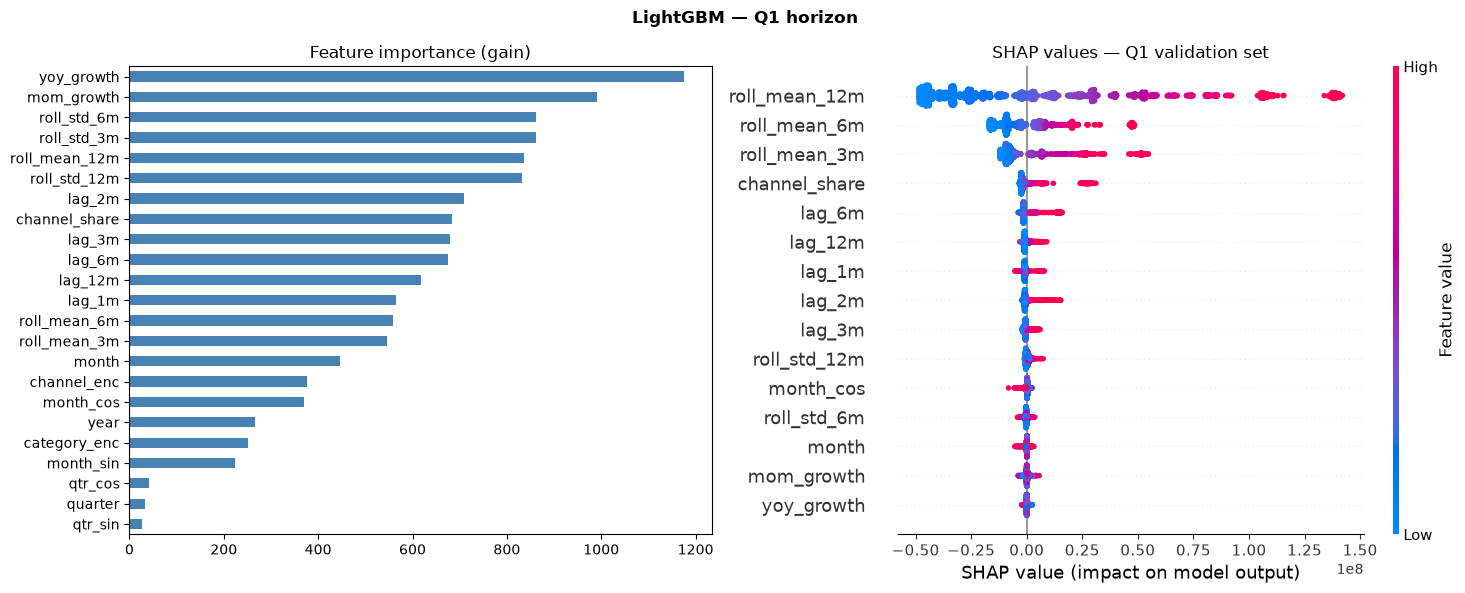

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('LightGBM — Q1 horizon', fontweight='bold')

# Feature importance
imp = pd.Series(lgbm_models['Q1'].feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature importance (gain)')

# SHAP
df_q1 = monthly.copy()
df_q1['target'] = df_q1.groupby('group_id')['sales_amount'].shift(-3)
df_q1 = df_q1.dropna(subset=['target'])
X_va_q1 = df_q1[df_q1['date'] >= cutoff_date][FEATURES]

explainer   = shap.TreeExplainer(lgbm_models['Q1'])
shap_values = explainer.shap_values(X_va_q1)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_va_q1, max_display=15, show=False, plot_size=None)
axes[1].set_title('SHAP values — Q1 validation set')

plt.tight_layout()
plt.show()

## Step 9 — Model 2: Temporal Fusion Transformer (TFT)
11 years of data means we can give TFT a 24-month encoder window — much richer sequential context than before.

In [26]:
MAX_ENCODER = 24  # 2 years of history (was 6 months on old dataset)
MAX_PRED    = 3   # Q1 baseline

training_cutoff_idx = int(monthly['time_idx'].max() * 0.80)

known_reals   = ['month_sin', 'month_cos', 'qtr_sin', 'qtr_cos', 'time_idx']
unknown_reals = [
    'lag_1m', 'lag_2m', 'lag_3m', 'lag_6m', 'lag_12m',
    'roll_mean_3m', 'roll_mean_6m', 'roll_mean_12m',
    'channel_share', 'yoy_growth', 'mom_growth',
]

train_ds = TimeSeriesDataSet(
    monthly[monthly['time_idx'] <= training_cutoff_idx],
    time_idx                   = 'time_idx',
    target                     = 'sales_amount',
    group_ids                  = ['group_id'],
    min_encoder_length         = MAX_ENCODER // 2,
    max_encoder_length         = MAX_ENCODER,
    min_prediction_length      = 1,
    max_prediction_length      = MAX_PRED,
    static_categoricals        = ['channel', 'category'],
    time_varying_known_reals   = known_reals,
    time_varying_unknown_reals = unknown_reals + ['sales_amount'],
    target_normalizer          = GroupNormalizer(groups=['group_id'], transformation='softplus'),
    add_relative_time_idx      = True,
    add_target_scales          = True,
    add_encoder_length         = True,
)

val_ds = TimeSeriesDataSet.from_dataset(train_ds, monthly, predict=True, stop_randomization=True)

train_loader = train_ds.to_dataloader(train=True,  batch_size=64, num_workers=0, shuffle=True)
val_loader   = val_ds.to_dataloader(  train=False, batch_size=128, num_workers=0)

print(f'Train samples: {len(train_ds):,}')
print(f'Val samples  : {len(val_ds):,}')

Train samples: 10,584
Val samples  : 168


In [29]:
tft = TemporalFusionTransformer.from_dataset(
    train_ds,
    learning_rate          = 1e-3,
    hidden_size            = 64,    # larger than before — more data to learn from
    attention_head_size    = 4,
    dropout                = 0.1,
    hidden_continuous_size = 32,
    loss                   = QuantileLoss(quantiles=[0.1, 0.5, 0.9]),
    log_interval           = 10,
    reduce_on_plateau_patience = 4,
)

print(f'TFT parameters: {sum(p.numel() for p in tft.parameters()):,}')

trainer = pl.Trainer(
    max_epochs        = 50,
    accelerator       = 'auto',
    gradient_clip_val = 0.1,
    callbacks         = [
        EarlyStopping(monitor='val_loss', patience=6, mode='min'),
        ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1),
    ],
    enable_progress_bar = True,
    logger              = False,
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
print('TFT training done.')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


TFT parameters: 403,814



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 170    | train | 0    
3  | prescalers                         | ModuleDict                      | 1.3 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 21.2 K | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 133 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 42.0 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train | 0    
8  

Epoch 10: 100%|██████████| 165/165 [01:13<00:00,  2.24it/s, train_loss_step=3.69e+6, val_loss=6.49e+6, train_loss_epoch=4.34e+6]
TFT training done.


In [32]:
import pytorch_forecasting
print(pytorch_forecasting.__version__)
pred = best_tft.predict(
    val_loader,
    mode="raw",
    return_index=True
)
print(type(pred))
print(pred)

1.8.0
<class 'pytorch_forecasting.models.base._base_model.Prediction'>
Prediction(output=Output(prediction=tensor([[[6.8568e+07, 8.5650e+07, 1.0276e+08],
         [6.4710e+07, 8.0004e+07, 9.7074e+07],
         [6.6876e+07, 8.3040e+07, 9.9109e+07]],

        [[1.3288e+07, 1.5319e+07, 1.7809e+07],
         [1.3066e+07, 1.4990e+07, 1.7398e+07],
         [1.3441e+07, 1.5538e+07, 1.7766e+07]],

        [[5.9687e+07, 7.1208e+07, 8.3707e+07],
         [5.8903e+07, 7.0225e+07, 8.2814e+07],
         [6.1707e+07, 7.4099e+07, 8.5637e+07]],

        ...,

        [[4.3270e+07, 4.8390e+07, 5.4532e+07],
         [4.2612e+07, 4.7336e+07, 5.3272e+07],
         [4.3649e+07, 4.8807e+07, 5.4288e+07]],

        [[7.9932e+07, 8.9736e+07, 1.0198e+08],
         [7.7359e+07, 8.6046e+07, 9.7904e+07],
         [8.0644e+07, 9.0934e+07, 1.0198e+08]],

        [[8.1850e+07, 9.2459e+07, 1.0561e+08],
         [8.0984e+07, 9.1338e+07, 1.0472e+08],
         [8.4000e+07, 9.5731e+07, 1.0787e+08]]]), encoder_attention=te

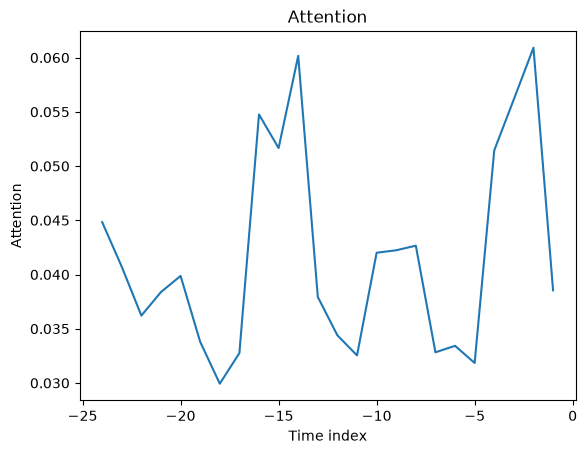

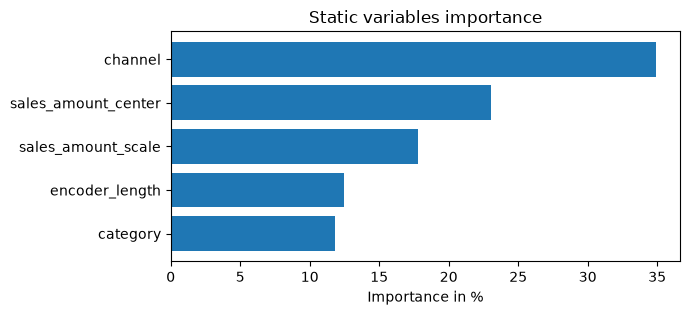

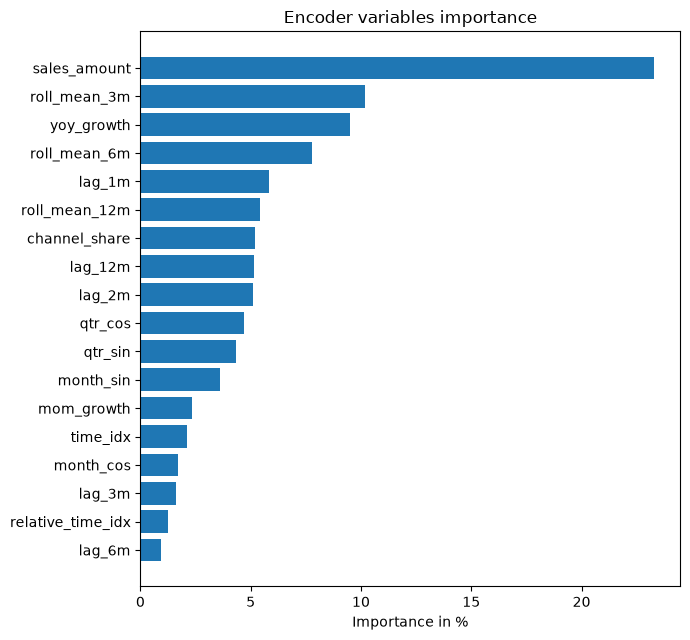

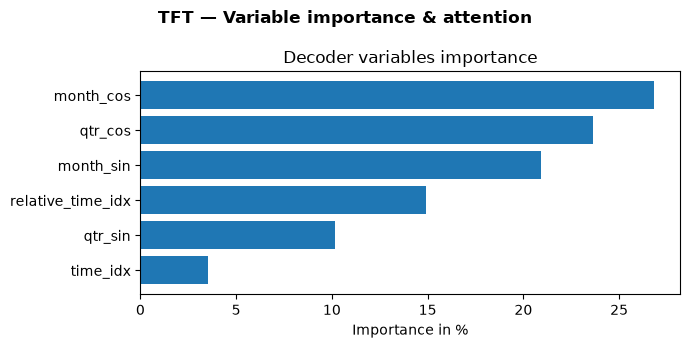

TFT predictions ready.


In [31]:
best_tft  = TemporalFusionTransformer.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

pred = best_tft.predict(
    val_loader,
    mode="raw",
    return_index=True
)

tft_raw = pred.output
tft_index = pred.index

tft_p50 = best_tft.predict(val_loader, mode='prediction')  # median forecast

# Variable importance and attention weights
interpretation = best_tft.interpret_output(tft_raw, reduction='sum')
best_tft.plot_interpretation(interpretation)
plt.suptitle('TFT — Variable importance & attention', fontweight='bold')
plt.tight_layout()
plt.show()

print('TFT predictions ready.')

## Step 10 — Model 3: GARCH-X
Models volatility clustering across the 11-year revenue series — calibrates confidence interval width.

In [34]:
total_monthly = monthly.groupby('date')['sales_amount'].sum().sort_index()
returns       = total_monthly.pct_change().dropna() * 100

garch_model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
garch_fit   = garch_model.fit(disp='off')
print(garch_fit.summary())

garch_forecast = garch_fit.forecast(horizon=12)  # forecast 12 months of volatility
forecast_var   = garch_forecast.variance.values[-1]
forecast_std   = np.sqrt(forecast_var)

print(f'\nGARCH volatility forecast (next 12 months): {np.round(forecast_std, 4)}')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:           sales_amount   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -235.912
Distribution:                  Normal   AIC:                           479.823
Method:            Maximum Likelihood   BIC:                           489.250
                                        No. Observations:                   78
Date:                Mon, Jun 29 2026   Df Residuals:                       77
Time:                        22:16:23   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0150     18.448  8.131e-04      0.999 [-36.143, 36.17

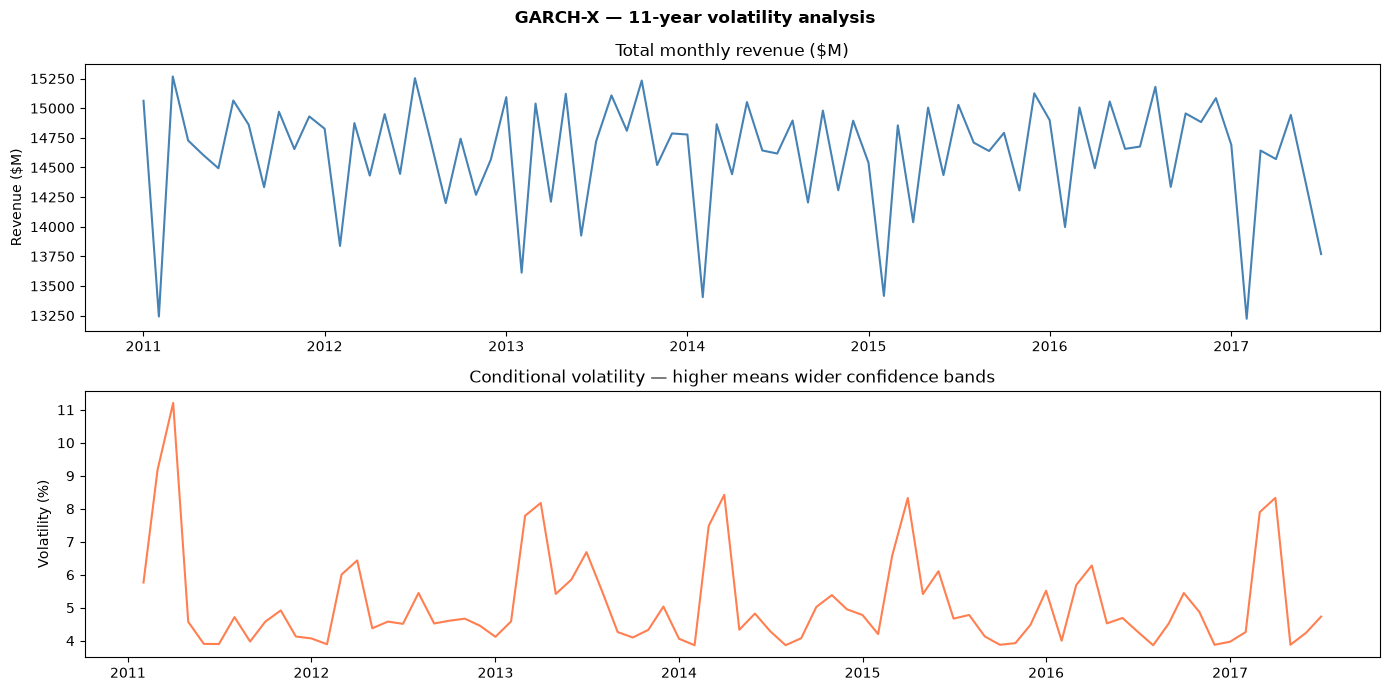

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('GARCH-X — 11-year volatility analysis', fontweight='bold')

axes[0].plot(total_monthly.index, total_monthly.values / 1e6, color='steelblue', linewidth=1.5)
axes[0].set_title('Total monthly revenue ($M)')
axes[0].set_ylabel('Revenue ($M)')

axes[1].plot(returns.index, garch_fit.conditional_volatility, color='coral', linewidth=1.5)
axes[1].set_title('Conditional volatility — higher means wider confidence bands')
axes[1].set_ylabel('Volatility (%)')

plt.tight_layout()
plt.show()

## Step 11 — Meta-Learner: Stacking
Ridge regression combines LightGBM + TFT into a single forecast per horizon.

In [36]:
tft_p50_np = tft_p50.numpy() if hasattr(tft_p50, 'numpy') else np.array(tft_p50)
tft_series = pd.Series(tft_p50_np[:, 0], index=tft_index.index)

meta_models  = {}
meta_results = {}

for label, h in HORIZONS.items():
    lgbm_idx = lgbm_preds[label]['index']
    common   = lgbm_idx.intersection(tft_series.index)

    if len(common) < 10:
        print(f'{label}: not enough overlap — skipping meta-learner.')
        continue

    lgbm_p = pd.Series(lgbm_preds[label]['preds'], index=lgbm_idx).loc[common].values
    tft_p  = tft_series.loc[common].values

    df_h           = monthly.copy()
    df_h['target'] = df_h.groupby('group_id')['sales_amount'].shift(-h)
    df_h           = df_h.dropna(subset=['target'])
    y_meta         = df_h['target'].loc[common].values

    X_meta = np.column_stack([lgbm_p, tft_p])
    meta   = Ridge(alpha=1.0)
    meta.fit(X_meta, y_meta)
    preds  = meta.predict(X_meta)

    meta_models[label]  = meta
    meta_results[label] = {
        'preds': preds, 'actuals': y_meta,
        'wape' : wape(y_meta, preds),
        'rmse' : mean_squared_error(y_meta, preds),
        'lgbm_w': meta.coef_[0], 'tft_w': meta.coef_[1],
    }

    print(f'{label:8s} | WAPE: {wape(y_meta, preds):>6.2f}%  '
          f'RMSE: {mean_squared_error(y_meta, preds):>12,.2f}  '
          f'LGB weight: {meta.coef_[0]:.3f}  TFT weight: {meta.coef_[1]:.3f}')

Q1       | WAPE:   8.37%  RMSE: 33,999,423,910,459.88  LGB weight: 0.987  TFT weight: -0.004
H1       | WAPE:   9.43%  RMSE: 40,744,644,825,015.67  LGB weight: 0.961  TFT weight: 0.014
Annual: not enough overlap — skipping meta-learner.


## Step 12 — Evaluation: Accuracy across all models & horizons

In [37]:
print(f'{"Horizon":<10} {"Model":<18} {"Train MAE":>14} {"Test MAE":>14} {"WAPE%":>8} {"RMSE":>14}')
print('─' * 72)

for label in HORIZONS:
    l = lgbm_preds[label]
    print(f'{label:<10} {"LightGBM":<18} {l["train_mae"]:>14,.2f} {l["test_mae"]:>14,.2f} '
          f'{l["wape"]:>7.2f}%  {l["rmse"]:>14,.2f}')
    if label in meta_results:
        m = meta_results[label]
        print(f'{"":<10} {"Meta (LGB+TFT)":<18} {"":>14} {"":>14} '
              f'{m["wape"]:>7.2f}%  {m["rmse"]:>14,.2f}')
    print()

Horizon    Model                   Train MAE       Test MAE    WAPE%           RMSE
────────────────────────────────────────────────────────────────────────
Q1         LightGBM             6,705,519.77   9,367,969.70   10.81%  251,069,448,387,212.47
           Meta (LGB+TFT)                                      8.37%  33,999,423,910,459.88

H1         LightGBM             6,855,314.27   9,366,884.03   10.84%  241,345,151,184,063.34
           Meta (LGB+TFT)                                      9.43%  40,744,644,825,015.67

Annual     LightGBM             7,402,355.84   9,519,430.44   11.10%  253,649,302,584,201.81



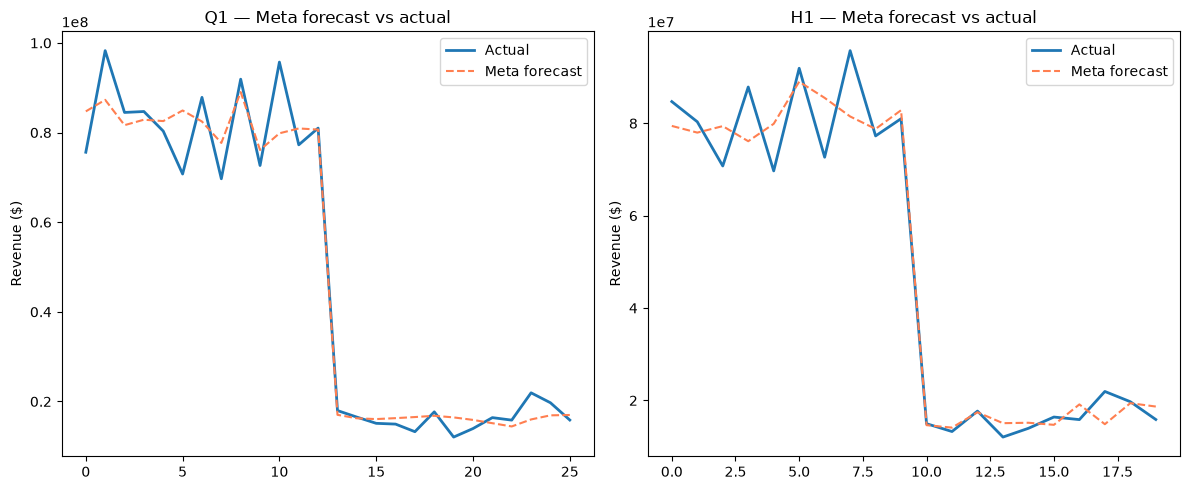

In [56]:
available = [l for l in HORIZONS if l in meta_results]
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, label in zip(axes, available):
        m = meta_results[label]
        n = min(100, len(m['actuals']))
        ax.plot(m['actuals'][:n], label='Actual', linewidth=2)
        ax.plot(m['preds'][:n],   label='Meta forecast', linewidth=1.5,
                linestyle='--', color='coral')
        ax.set_title(f'{label} — Meta forecast vs actual')
        ax.legend()
        ax.set_ylabel('Revenue ($)')
    plt.tight_layout()
    plt.show()

## Step 13 — Output Layer
Point forecast + GARCH-calibrated confidence bands (P10/P50/P90) + directional signal.

In [57]:
latest = monthly.sort_values('date').groupby('group_id').last().reset_index()

horizon_to_garch_idx = {'Q1': 2, 'H1': 5, 'Annual': 11}  # index into 12-month forecast_std

rows = []
for label, h in HORIZONS.items():
    if label not in lgbm_models:
        continue
    point     = lgbm_models[label].predict(latest[FEATURES])
    garch_vol = forecast_std[horizon_to_garch_idx[label]]

    for i, (_, row) in enumerate(latest.iterrows()):
        p   = point[i]
        bw  = row['sales_amount'] * (garch_vol / 100)
        chg = (p - row['sales_amount']) / (row['sales_amount'] + 1e-9) * 100
        rows.append({
            'region'      : row['channel'].split(' — ')[0],
            'sales_channel': row['channel'].split(' — ')[1],
            'item_type'   : row['category'],
            'horizon'     : label,
            'last_actual' : round(row['sales_amount'], 2),
            'P50_forecast': round(p, 2),
            'P10_lower'   : round(max(0, p - bw), 2),
            'P90_upper'   : round(p + bw, 2),
            'change_pct'  : round(chg, 1),
            'direction'   : '▲ Up' if chg > 2 else ('▼ Down' if chg < -2 else '→ Flat'),
        })

output = pd.DataFrame(rows).sort_values(['region', 'item_type', 'horizon'])
print('── Forecast Output (sample — first 18 rows) ────────────────────────')
print(output.head(18).to_string(index=False))

── Forecast Output (sample — first 18 rows) ────────────────────────
region sales_channel item_type horizon  last_actual  P50_forecast   P10_lower   P90_upper  change_pct direction
  Asia       Offline Baby Food  Annual  80997791.20   78708063.80 74393619.82 83022507.77        -2.8    ▼ Down
  Asia        Online Baby Food  Annual  88628110.40   85295686.27 80574804.24 90016568.30        -3.8    ▼ Down
  Asia       Offline Baby Food      H1  80997791.20   86693778.82 82389364.74 90998192.89         7.0      ▲ Up
  Asia        Online Baby Food      H1  88628110.40   88934001.21 84224093.94 93643908.48         0.3    → Flat
  Asia       Offline Baby Food      Q1  80997791.20   81176453.87 76958096.87 85394810.88         0.2    → Flat
  Asia        Online Baby Food      Q1  88628110.40   88824008.40 84208265.12 93439751.68         0.2    → Flat
  Asia       Offline Beverages  Annual  15860969.15   16157361.59 15312508.14 17002215.03         1.9    → Flat
  Asia        Online Beverages  Ann

## Step 14 — Accuracy by Region & Item Type

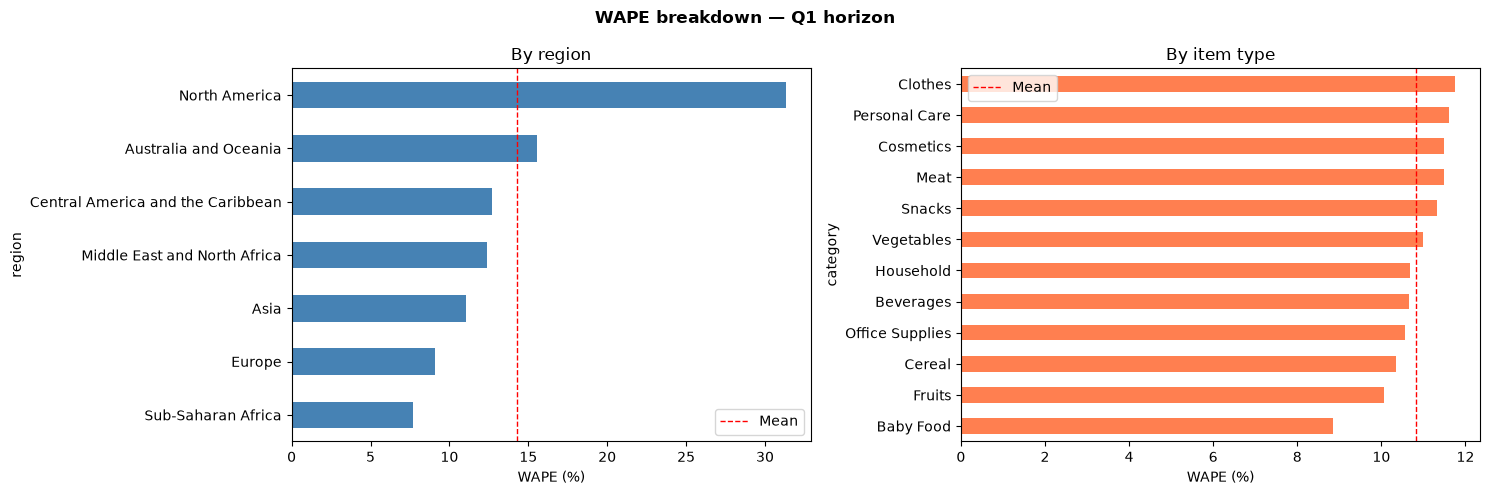

In [58]:
df_q1           = monthly.copy()
df_q1['target'] = df_q1.groupby('group_id')['sales_amount'].shift(-3)
df_q1           = df_q1.dropna(subset=['target'])
va_q1           = df_q1[df_q1['date'] >= cutoff_date].copy()
va_q1['pred']   = lgbm_models['Q1'].predict(va_q1[FEATURES])
va_q1['region'] = va_q1['channel'].str.split(' — ').str[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('WAPE breakdown — Q1 horizon', fontweight='bold')

reg_wape = (
    va_q1.groupby('region')
         .apply(lambda g: wape(g['target'].values, g['pred'].values))
         .sort_values()
)
reg_wape.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(reg_wape.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('By region')
axes[0].set_xlabel('WAPE (%)')
axes[0].legend()

cat_wape = (
    va_q1.groupby('category')
         .apply(lambda g: wape(g['target'].values, g['pred'].values))
         .sort_values()
)
cat_wape.plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(cat_wape.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('By item type')
axes[1].set_xlabel('WAPE (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 15 — Final forecast table for all consumers

In [38]:
print('=== Demand Planners (Region × Item Type — Q1 view) ===')
print(output[output['horizon'] == 'Q1'][[
    'region', 'sales_channel', 'item_type', 'last_actual', 'P50_forecast', 'direction'
]].to_string(index=False))

print('\n=== Finance / FP&A (Confidence bands by region — all horizons) ===')
finance = (
    output.groupby(['region', 'horizon'])[['P10_lower', 'P50_forecast', 'P90_upper']]
          .sum().reset_index()
)
print(finance.to_string(index=False))

print('\n=== Executives (Directional roll-up by horizon) ===')
exec_view = (
    output.groupby(['horizon', 'direction'])
          .size().reset_index(name='group_count')
          .sort_values(['horizon', 'group_count'], ascending=[True, False])
)
print(exec_view.to_string(index=False))

=== Demand Planners (Region × Item Type — Q1 view) ===


NameError: name 'output' is not defined